In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

BASE_DIR = Path.cwd().parent
file_path = BASE_DIR / "data" / "raw" / "Online_Retail.xlsx"

df = pd.read_excel(file_path)

In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
df.astype({"InvoiceNo": "str", "StockCode": "str", "Description": "str"}).dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [6]:
df.describe().T  

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


# Things to Investigate
---
## Duplicates  
1. Does the dataset contain duplicate rows? If so, remove them

---
## Quantity  
1. Minimum value of 'Quantity' is negative, which is a sign of bad data
2. Explore how many rows contain negative quantity values. If it is a small percentage (less than 20%) of the total data, remove such rows. Otherwise, work under the assumption that their absolute values are correct  
3. Check the distribution of 'Quantity' values  
---
## UnitPrice  
1. Minimum value of 'UnitPrice' is negative, which is a sign of bad data  
---
## CustomerID  
1. Contains roughly 135k (~25% of the total data) null values


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.duplicated().sum()
df[df.duplicated(keep=False)]
deduped_df = df.drop_duplicates()

deduped_df.shape

(536641, 8)

In [9]:
deduped_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
total_orders = deduped_df['InvoiceNo'].nunique()
print(f'Total orders: {total_orders}')

# For a fixed invoice number, the CustomerID should always be consistent
inconsistent = any(df.dropna(subset=["CustomerID"]).groupby("InvoiceNo")["CustomerID"].nunique().gt(1)) 
print(f'The file contains records with mismatching InvoiceNo and CustomerID: {inconsistent}') # False 

Total orders: 25900
The file contains records with mismatching InvoiceNo and CustomerID: False


# Individual Variable Exploration


## 1. Quantity

In [11]:
neg_qty = (deduped_df['Quantity'] < 0).sum()
print(f'Count of rows with negative quantity: \n{neg_qty}') # 10587 rows (roughly 2% of all data) with negative Quantity values 

Count of rows with negative quantity: 
10587


In [12]:
clean_qty_df = (deduped_df[deduped_df['Quantity'] > 0]) # remove rows containing negative Quantity values
clean_qty_df.shape

(526054, 8)

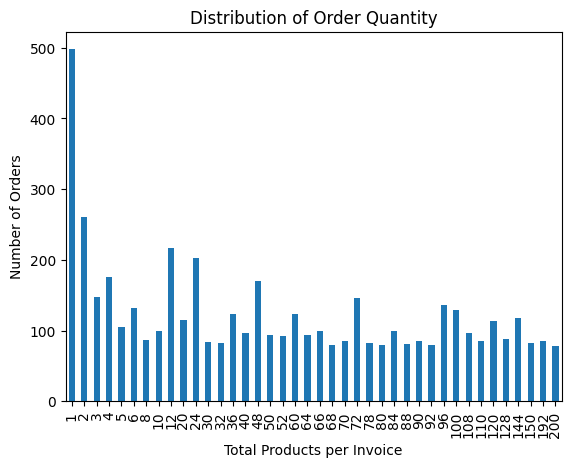

In [13]:
order_qty = clean_qty_df.groupby('InvoiceNo')['Quantity'].sum()
order_qty.value_counts().head(40).sort_index().plot(kind='bar')

plt.title("Distribution of Order Quantity")
plt.xlabel("Total Products per Invoice")
plt.ylabel("Number of Orders")
plt.show()

# 2. Unit Price

In [14]:
neg_up = (clean_qty_df['UnitPrice'] < 0).sum()
print(f'Count of rows with negative quantity: {neg_up}') # only 2 rows contain negative unit price 

Count of rows with negative quantity: 2


In [15]:
clean_qty_df[clean_qty_df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [16]:
clean_up_df = (clean_qty_df[clean_qty_df['UnitPrice'] > 0])

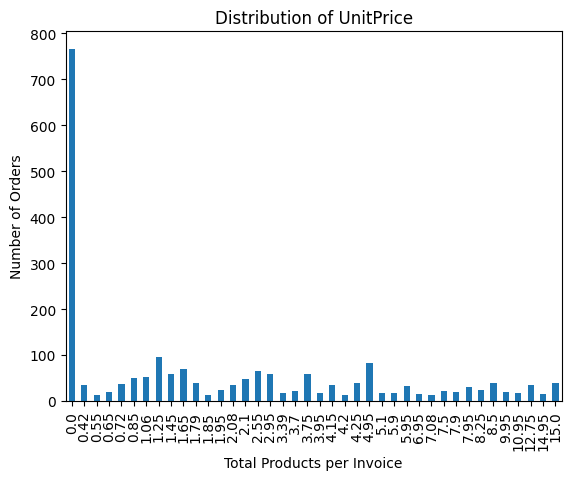

In [17]:
order_up = clean_qty_df.groupby('InvoiceNo')['UnitPrice'].sum()
order_up.value_counts().head(40).sort_index().plot(kind='bar')

plt.title("Distribution of UnitPrice")
plt.xlabel("Total Products per Invoice")
plt.ylabel("Number of Orders")
plt.show()

# 3. CustomerID

In [18]:
null_cid_df = clean_up_df[clean_up_df['CustomerID'].isnull()]
num_orders = null_cid_df["InvoiceNo"].nunique() # How many orders were placed by customers with missing CustomerID?
print(f'{num_orders} out of {total_orders} (~{round(num_orders/total_orders * 100, 2)}%) orders were placed by customers with missing CustomerID')

1428 out of 25900 (~5.51%) orders were placed by customers with missing CustomerID


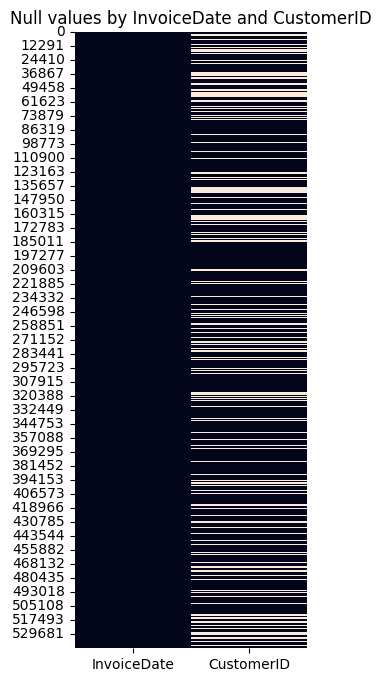

In [19]:
clean_up_df = clean_up_df.sort_values('InvoiceDate')

plt.figure(figsize=(3, 8))
sns.heatmap(
    clean_up_df[['InvoiceDate', 'CustomerID']].isnull(),
    cbar=False
)
plt.title('Null values by InvoiceDate and CustomerID')
plt.show()

In [20]:
clean_up_df.describe().T  

,count,mean,min,25%,50%,75%,max,std
Quantity,524878.0,10.6166,1.0,1.0,4.0,11.0,80995.0,156.280031
InvoiceDate,524878,2011-07-04 15:30:16.317049,2010-12-01 08:26:00,2011-03-28 12:13:00,2011-07-20 11:22:00,2011-10-19 11:41:00,2011-12-09 12:50:00,NaN
UnitPrice,524878.0,3.922573,0.001,1.25,2.08,4.13,13541.33,36.093028
CustomerID,392692.0,15287.843865,12346.0,13955.0,15150.0,16791.0,18287.0,1713.539549


In [21]:
path = BASE_DIR / "data" / "clean"  

clean_up_df.to_csv(os.path.join(path,r'clean_retail.csv'), index=False) 

In [23]:
clean_up_df[clean_up_df['Description'] == 'MEDIUM CERAMIC TOP STORAGE JAR']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
186770,552882,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,2011-05-12 10:10:00,1.04,14646.0,Netherlands
187196,552953,23166,MEDIUM CERAMIC TOP STORAGE JAR,4,2011-05-12 12:11:00,1.25,16745.0,United Kingdom
187718,553005,23166,MEDIUM CERAMIC TOP STORAGE JAR,5,2011-05-12 16:29:00,1.25,14651.0,United Kingdom
187868,553009,23166,MEDIUM CERAMIC TOP STORAGE JAR,3,2011-05-12 16:52:00,1.25,13601.0,United Kingdom
...,...,...,...,...,...,...,...,...
533742,581108,23166,MEDIUM CERAMIC TOP STORAGE JAR,2,2011-12-07 12:16:00,1.25,15984.0,United Kingdom
536248,581219,23166,MEDIUM CERAMIC TOP STORAGE JAR,1,2011-12-08 09:28:00,2.46,NaN,United Kingdom
539776,581439,23166,MEDIUM CERAMIC TOP STORAGE JAR,2,2011-12-08 16:30:00,2.46,NaN,United Kingdom
540301,581476,23166,MEDIUM CERAMIC TOP STORAGE JAR,48,2011-12-09 08:48:00,1.04,12433.0,Norway
